# 9.1.2 后验曲率边界与参数变换

## 学习目标与先修知识

用积分核对清除率的局部近似，解释边界、多峰与参数（parameter）变换。

先修：9.1.1的后验（posterior）归一化，第2篇指数清除，第8篇导数（derivative）、曲率及一维极小化。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

同一条清除曲线可以支持一个偏斜的正参数后验。用模态（mode）和曲率画出的钟形曲线，会不会在k<0处放置概率（probability），或者遗漏另一个峰？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先用可解析的Gamma后验区分均值、模态和局部方差（variance）。先验（prior）形状2、率1，事件（event）计数2、暴露时长3。

In [2]:
a,b=2+2,1+3
print("均值、模态、精确方差、局部方差：",a/b,(a-1)/b,a/b**2,(a-1)/b**2)

均值、模态、精确方差、局部方差： 1.0 0.75 0.25 0.1875


## 模型假设

主实验为无输入（input）理想单室，A(t)=A₀exp(−kt)，A₀=5 U已知，k>0，t以T计。读数为A(t)加独立N(0,r)噪声，r=.16 U²。先验k服从Gamma(a=2,b=4 T)，b采用率参数化。观测（observation）时间与测量方差固定，不把负的有噪读数直接裁剪。先用Poisson计数小例核对Gamma边界，再用一维积分核对非线性观测后验；两组实验分别采用各自的似然（likelihood）。

## 数学解释与推导

记负对数未归一化后验为f。若模态 $\hat k$ 位于支持内部、$f'(\hat k)=0$ 且曲率 $H=f''(\hat k)>0$，二阶展开给出
$$f(k)\approx f(\hat k)+\tfrac12H(k-\hat k)^2,\qquad p(k\mid y)\approx N(\hat k,H^{-1}).$$
这是Laplace近似，只描述该模态附近；远尾、支持边界和其他模态不由这张二阶曲线保证。H的单位为T²，方差单位为1/T²。

对于独立事件计数 $c\sim\mathrm{Poisson}(kE)$ 和Gamma(a,b)先验，后验形状a′=a+c、率b′=b+E。其负对数为 $b'k-(a'-1)\log k+C$。a′>1时，模态 $(a'-1)/b'$，曲率 $b'^2/(a'-1)$，而精确均值a′/b′、方差a′/b′²。a′≤1时没有可用的内点模态；不能继续套内点高斯公式。

主清除模型（model）中令 $m_i(k)=A_0e^{-kt_i}$，则
$$f(k)=\sum_i\frac{(m_i(k)-y_i)^2}{2r}+bk-(a-1)\log k+C,$$
$$f'(k)=\sum_i\frac{-t_i m_i(m_i-y_i)}r+b-\frac{a-1}k,\quad f''(k)=\sum_i\frac{t_i^2m_i(2m_i-y_i)}r+\frac{a-1}{k^2}.$$
先扫描区间，再细化最低的候选盆地；扫描本身不构成一般全局最优证明。积分使用节点间距，等距时首末梯形权重也不同。log-sum-exp先减最大值再指数，可避免直接计算极小密度下溢。

若改坐标为η=log k，必须有 $p_\eta(\eta\mid y)=p_k(e^\eta\mid y)e^\eta$。同一概率事件在变换前后不变，但密度模态可能改变。把横轴改名而忘掉雅可比，会得到另一个分布（distribution）。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def clearance_loss(rate,times,observations,initial,noise,shape,prior_rate):
    if rate<=0:return math.inf
    residuals=[initial*math.exp(-rate*t)-y for t,y in zip(times,observations)]
    return sum(r*r for r in residuals)/(2*noise)+prior_rate*rate-(shape-1)*math.log(rate)


def clearance_local(times,observations,initial,noise,shape,prior_rate,lower,upper):
    # Bracket the best coarse-grid basin, then minimize within that basin.
    nodes=[lower+(upper-lower)*i/1000 for i in range(1001)]
    loss=lambda k:clearance_loss(k,times,observations,initial,noise,shape,prior_rate)
    j=min(range(len(nodes)),key=lambda i:loss(nodes[i]))
    if j in (0,1000):raise ValueError('搜索边界可能截断模态，需要扩大范围')
    left,right=nodes[j-1],nodes[j+1]
    ratio=(math.sqrt(5)-1)/2
    for _ in range(70):
        x=right-ratio*(right-left);y=left+ratio*(right-left)
        if loss(x)<loss(y):right=y
        else:left=x
    mode=(left+right)/2
    curve=sum(t*t*(initial*math.exp(-mode*t))*(2*initial*math.exp(-mode*t)-y)/noise for t,y in zip(times,observations))+(shape-1)/mode**2
    if curve<=0:raise ValueError('曲率不能定义局部高斯方差')
    return mode,curve,1/curve


def logsumexp(values):
    top=max(values)
    return top+math.log(sum(math.exp(x-top) for x in values))


def grid_posterior(nodes,log_values):
    # Trapezoidal integration: endpoint nodes receive half interval weights.
    widths=[(nodes[1]-nodes[0])/2]+[(nodes[i+1]-nodes[i-1])/2 for i in range(1,len(nodes)-1)]+[(nodes[-1]-nodes[-2])/2]
    log_mass=[l+math.log(w) for l,w in zip(log_values,widths)]
    normalizer=logsumexp(log_mass)
    weights=[math.exp(l-normalizer) for l in log_mass]
    mean=sum(w*x for w,x in zip(weights,nodes))
    variance=sum(w*(x-mean)**2 for w,x in zip(weights,nodes))
    return weights,mean,variance,normalizer


def gamma_local(shape,rate,count,exposure):
    a,b=shape+count,rate+exposure
    if a<=1:return None,None,None,'boundary'
    mode=(a-1)/b;curvature=(a-1)/mode**2
    return mode,curvature,1/curvature,'interior'


def normal_logpdf(value,mean,variance):
    return -.5*(math.log(2*math.pi*variance)+(value-mean)**2/variance)

## 对照实验

使用固定教学读数，在同一先验和似然下比较积分后验与局部高斯；同时画Gamma形状1和4的边界/内点反例。

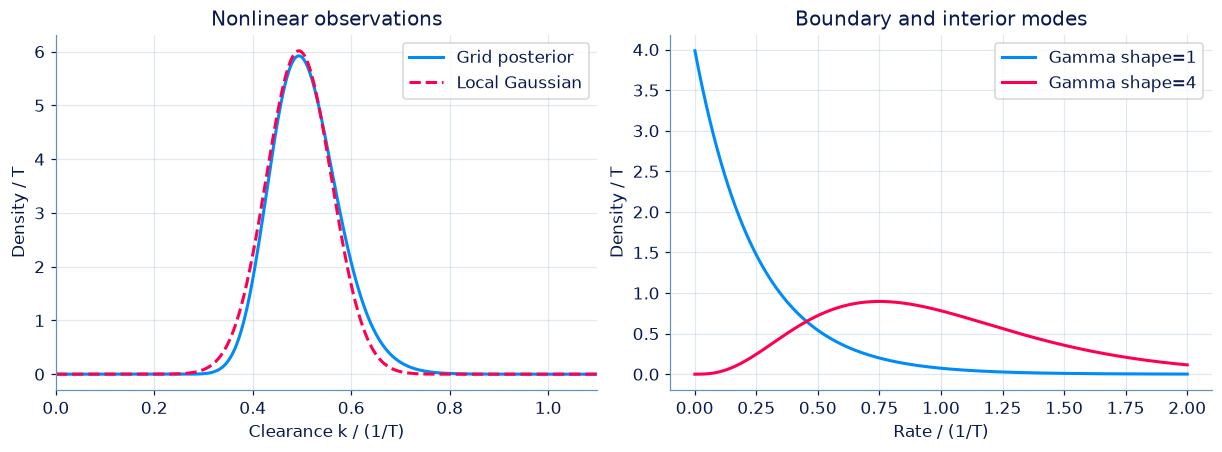

| 参照 | 中心 / (1/T) | 方差 / (1/T²) |
| --- | --- | --- |
| 网格矩 | 0.507472 | 0.00483019 |
| 局部高斯 | 0.493577 | 0.00439926 |

In [4]:
times=[0.,1.,2.,3.];observed=[5.1,3.2,1.6,1.2]
nodes=np.linspace(.0001,4,4001);logs=[-clearance_loss(k,times,observed,5,.16,2,4) for k in nodes]
w,mean,var,logZ=grid_posterior(nodes.tolist(),logs);mode,curvature,local_var=clearance_local(times,observed,5,.16,2,4,.0001,4)
fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].plot(nodes,np.exp(np.array(logs)-logZ),label='Grid posterior');axes[0].plot(nodes,np.exp([normal_logpdf(k,mode,local_var) for k in nodes]),'--',label='Local Gaussian');axes[0].set(xlim=(0,1.1),xlabel='Clearance k / (1/T)',ylabel='Density / T',title='Nonlinear observations');axes[0].legend()
x=np.linspace(.001,2,400)
for a in [1,4]:axes[1].plot(x,4**a/math.gamma(a)*x**(a-1)*np.exp(-4*x),label=f'Gamma shape={a}')
axes[1].set(xlabel='Rate / (1/T)',ylabel='Density / T',title='Boundary and interior modes');axes[1].legend();plt.show()
display(Markdown(show_table(['参照','中心 / (1/T)','方差 / (1/T²)'],[('网格矩',mean,var),('局部高斯',mode,local_var)])))

## 结果解释

均值、模态和曲率回答不同问题。图中主清除例的局部高斯可能很接近高密度区域，但仍要查看尾部与积分参照。右图形状1的最大密度出现在边界，形状4才有内点模态。MAP 随密度使用的坐标而变化，比较时需要同时注明参数化。

### 独立核对

同时检查网格加密和积分区间扩大；用有限差分（finite difference）核对解析曲率，再在log参数坐标重新积分验证概率变换。

In [5]:
fine=np.linspace(.00001,6,12001);fl=[-clearance_loss(k,times,observed,5,.16,2,4) for k in fine]
_,fm,fv,_=grid_posterior(fine.tolist(),fl);np.testing.assert_allclose([mean,var],[fm,fv],atol=2e-6)
h=1e-4;f=lambda k:clearance_loss(k,times,observed,5,.16,2,4)
assert abs((f(mode+h)-2*f(mode)+f(mode-h))/h**2-curvature)<1e-3
eta=np.linspace(-12,math.log(6),10001);ks=np.exp(eta)
ew,_,_,_=grid_posterior(eta.tolist(),[-f(k)+e for k,e in zip(ks,eta)])
np.testing.assert_allclose(sum(p*k for p,k in zip(ew,ks)),fm,atol=2e-6)
assert gamma_local(1,1,0,1)[-1]=='boundary'
print('区间/网格、独立差分及含Jacobian的坐标积分通过。')

区间/网格、独立差分及含Jacobian的坐标积分通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/09-01-贝叶斯建模与后验近似/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：检查局部近似能否成立

独立事件（event）计数服从Poisson(kE)，正参数（parameter）k有Gamma(a,b)先验（prior），b采用率参数化。计算内点模态（mode）及局部曲率，并按规则处理边界情形。

**函数与代码模板**

```python
def solve(
    shape: float,
    rate: float,
    count: int,
    exposure: float,
) -> tuple[float | None, float | None, float | None, str]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `shape` | `float` | Gamma先验形状a。 | 1 |
| `rate` | `float` | Gamma先验率b，密度含exp(−bk)。 | T |
| `count` | `int` | Poisson事件总数c。 | 1 |
| `exposure` | `float` | 已知暴露时长E，事件均值为kE。 | T |

**返回值**

按以下顺序返回元组：(mode, curvature, variance, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mode` | <code>float &#124; None</code> | 内点模态；边界情形为None。 | 1/T |
| `curvature` | <code>float &#124; None</code> | 负对数后验（posterior）在模态处的二阶导数（derivative）。 | T² |
| `variance` | <code>float &#124; None</code> | 局部高斯方差（variance），即曲率的倒数。 | 1/T² |
| `status` | `str` | interior或boundary。 | 不适用 |

**计算规则**

更新a′=a+c，b′=b+E；a′>1时mode=(a′−1)/b′，curvature=(a′−1)/mode²，variance=1/curvature；a′≤1统一返回(None,None,None,"boundary")。

**约束与边界**

- a,b>0；0≤c≤100；E≥0；a,b,E≤100。 E=0时仅允许c=0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| shape | Gamma先验形状a。 | 2 | 1 |
| rate | Gamma先验率b，密度含exp(−bk)。 | 1 | T |
| count | Poisson事件总数c。 | 2 | 1 |
| exposure | 已知暴露时长E，事件均值为kE。 | 3 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
shape = 2.0
rate = 1.0
count = 2
exposure = 3.0

result = solve(shape, rate, count, exposure)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mode | 内点模态；边界情形为None。 | 0.75 | 1/T |
| curvature | 负对数后验（posterior）在模态处的二阶导数（derivative）。 | ≈ 5.333333 | T² |
| variance | 局部高斯方差（variance），即曲率的倒数。 | 0.1875 | 1/T² |
| status | interior或boundary。 | interior | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.75,
                   5.333333333333333,
                   0.1875,
                   'interior')
```

**样例解释**

a′=4，b′=4，因此模态0.75、曲率16/3、近似方差3/16；后验均值为1，与模态不同。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：检查局部近似能否成立](http://127.0.0.1:8000/chapters/09-01-%E8%B4%9D%E5%8F%B6%E6%96%AF%E5%BB%BA%E6%A8%A1%E4%B8%8E%E5%90%8E%E9%AA%8C%E8%BF%91%E4%BC%BC/practice/?question=p09-gamma-local)

### 第 2 题 · Python 计算题：积分节点不等于等权样本

给定可能不等距的节点与对数密度，按梯形法转为节点质量。

**函数与代码模板**

```python
def solve(
    nodes: list[float],
    log_values: list[float],
) -> tuple[list[float], float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `nodes` | `list[float]` | 严格递增积分节点。 | 1/T |
| `log_values` | `list[float]` | 各节点的未归一化对数密度值；使用同一数值单位。 | 1 |

**返回值**

按以下顺序返回元组：(weights, mean, variance, log_integral)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `weights` | `list[float]` | 含梯形积分宽度的归一化节点质量。 | 1 |
| `mean` | `float` | 节点近似均值。 | 1/T |
| `variance` | `float` | 按节点质量计算的方差（variance）。 | 1/T² |
| `log_integral` | `float` | 当前有限区间积分的对数。 | 1 |

**计算规则**

首末宽度为相邻间隔的一半；内部为左右相邻跨度的一半。以log_value+log(width)做log-sum-exp归一化，再求加权矩。

**约束与边界**

- 2—100节点，位于[0,10]且间距≥1e−4；log_values有限且在[−1000,1000]。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| nodes | 严格递增积分节点。 | [0.0, 1.0, 3.0] | 1/T |
| log_values | 各节点的未归一化对数密度值；使用同一数值单位。 | [0.0, 0.0, 0.0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
nodes = [0.0, 1.0, 3.0]
log_values = [0.0, 0.0, 0.0]

result = solve(nodes, log_values)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| weights | 含梯形积分宽度的归一化节点质量。 | [0.16666666666666669, 0.5000000000000001, 0.33333333333333337] | 1 |
| mean | 节点近似均值。 | 1.5 | 1/T |
| variance | 按节点质量计算的方差（variance）。 | 1.25 | 1/T² |
| log_integral | 当前有限区间积分的对数。 | ≈ 1.098612 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.16666666666666669,
                    0.5000000000000001,
                    0.33333333333333337],
                   1.5,
                   1.2500000000000002,
                   1.0986122886681096)
```

**样例解释**

宽度为[0.5,1.5,1]，质量为[1/6,1/2,1/3]；节点均值1.5，节点方差1.25。粗网格的二阶矩不等于连续均匀分布（distribution）的精确方差。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：积分节点不等于等权样本](http://127.0.0.1:8000/chapters/09-01-%E8%B4%9D%E5%8F%B6%E6%96%AF%E5%BB%BA%E6%A8%A1%E4%B8%8E%E5%90%8E%E9%AA%8C%E8%BF%91%E4%BC%BC/practice/?question=p09-grid-masses)

### 第 3 题 · 多项选择题：模态会随参数化改变吗

k>0，令η=log k。由k的后验（posterior）密度构造η的后验密度时应怎样做？

- **A.** pη(η)=pk(expη)。
- **B.** pη(η)=pk(expη)expη。
- **C.** 两个参数（parameter）化下的概率（probability）事件（event）可一致，但密度众数不必对应。
- **D.** 不需要雅可比，只要把横轴改名。

[作答：模态会随参数化改变吗](http://127.0.0.1:8000/chapters/09-01-%E8%B4%9D%E5%8F%B6%E6%96%AF%E5%BB%BA%E6%A8%A1%E4%B8%8E%E5%90%8E%E9%AA%8C%E8%BF%91%E4%BC%BC/practice/?question=p09-coordinate-map)

### 第 4 题 · 单项选择题：一个漂亮的局部高斯

目标后验（posterior）有两个相距很远的峰，算法在左峰精确求出正曲率。哪项结论可靠？

- **A.** 已精确表示整个后验。
- **B.** 右峰不重要，因为左峰局部曲率为正。
- **C.** 只能说明左峰附近可构造局部近似，仍需检查遗漏质量。
- **D.** 扩大局部图像就能找回右峰概率（probability）。

[作答：一个漂亮的局部高斯](http://127.0.0.1:8000/chapters/09-01-%E8%B4%9D%E5%8F%B6%E6%96%AF%E5%BB%BA%E6%A8%A1%E4%B8%8E%E5%90%8E%E9%AA%8C%E8%BF%91%E4%BC%BC/practice/?question=p09-single-mode)

### 第 5 题 · 多项选择题：网格变密但区间未扩大

在k∈[0.1,0.5]上把网格从1000加密到2000点，矩几乎不变。哪些解释正确？

- **A.** 这支持当前区间内离散误差较小。
- **B.** 这证明区间外没有概率（probability）。
- **C.** 还应扩大积分区间检查截断误差（truncation error）。
- **D.** 若密度峰在边界，必须警惕区间截断。

[作答：网格变密但区间未扩大](http://127.0.0.1:8000/chapters/09-01-%E8%B4%9D%E5%8F%B6%E6%96%AF%E5%BB%BA%E6%A8%A1%E4%B8%8E%E5%90%8E%E9%AA%8C%E8%BF%91%E4%BC%BC/practice/?question=p09-grid-domain)

**进一步阅读**

[Murphy，Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html)：后验近似、采样与预测检验。